<a href="https://colab.research.google.com/github/infod3-ws/FIAP_Tech_Challenge_Fase_1/blob/main/notebooks/02_Modelo_Preditivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Tech Challenge — Fase 1 | Modelo Preditivo de NPS
## Requisito 4 — Estratégia Preditiva com Machine Learning

**Curso:** Pós-Graduação em Data Science & Inteligência Artificial — FIAP PosTech  
**Fase:** 1 — Fundamentos e Análise Exploratória

---

### Contexto

A análise exploratória mostrou que o NPS consolidado da empresa é de **−80 pontos**
e que 84% dos clientes são detratores. O problema está identificado.

A próxima pergunta natural é: **conseguimos prever isso antes de acontecer?**

Hoje o NPS é coletado *depois* que o cliente viveu toda a experiência. Quando a nota
chega, a oportunidade de reverter aquela jornada já foi embora.

Este notebook propõe um modelo de Machine Learning capaz de **identificar clientes
em risco de se tornar detratores ainda durante a jornada de compra** usando apenas
dados operacionais que já existem nos sistemas da empresa.

---

### 🧭 Pergunta que o Modelo Busca Responder

> *"Com base nos dados operacionais de um pedido, esse cliente tem perfil de detrator ou não?"*


---
## 1. Escolha da Estratégia — Regressão ou Classificação?

O requisito propõe duas abordagens possíveis. Vamos avaliar cada uma:

### Opção A — Regressão (estimar a nota exata de 0 a 10)
Prever um número exato como 6.3 ou 7.8 é tecnicamente possível, mas
operacionalmente pouco útil. O que a equipe de operações faz com a informação
de que um cliente vai dar nota 5.7 em vez de 4.9?

### Opção B — Classificação (categorizar o cliente)
Transformar o problema em categorias torna a saída do modelo **acionável**.
Dizer que "esse cliente tem 83% de probabilidade de ser detrator" é uma
frase que um gestor entende e sobre a qual pode agir imediatamente.

### ✅ Decisão: Classificação Binária — Detrator vs. Não-Detrator

Optamos por uma classificação binária (duas categorias) em vez de três
(Detrator / Neutro / Promotor) por uma razão prática de negócio:

> A empresa precisa saber **quem está em risco** e agir sobre esse grupo.
> A distinção entre Neutro e Promotor, neste momento, é secundária.
> O foco é evitar detratores.

| | Regressão | Classificação 3 classes | **Classificação Binária ✅** |
|---|---|---|---|
| Interpretação | Difícil | Média | Fácil |
| Ação operacional | Baixa | Média | Alta |
| Adequação ao problema | Parcial | Boa | Ótima |

> 💬 Isso será como um sistema de alerta médico. Não precisamos saber o nível exato de pressão de cada paciente a todo momento, precisamos saber quem está em zona de risco para agir antes da crise.


---
## 2. Preparação do Ambiente


In [ ]:
# ============================================================
# BIBLIOTECAS
# pandas / numpy      → manipulação de dados
# sklearn             → construção, treino e avaliação do modelo
# matplotlib/seaborn  → visualizações
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Ambiente configurado com sucesso!')


✅ Ambiente configurado com sucesso!


---
## 3. Carregamento da Base e Definição da Variável Alvo

### 3.1 Variável Alvo (Target)

A variável alvo é derivada do `nps_score` já existente na base.
Transformamos a nota numérica em uma classificação binária:

- **1 → Detrator** (nota de 0 a 6.9)  
- **0 → Não-Detrator** (nota de 7 a 10, ou seja, Neutro ou Promotor)

### Por que essa variável foi escolhida?

Porque ela representa diretamente o que queremos prever: a insatisfação do cliente.
É a variável que captura a percepção subjetiva sobre toda a jornada de compra,
e é a métrica que o negócio já usa para tomar decisões estratégicas.

### Risco importante: Data Leakage (Vazamento de Dados)

Duas variáveis da base serão **excluídas** do modelo mesmo sendo
numericamente correlacionadas com o NPS:

- `repeat_purchase_30d` → se o cliente voltou a comprar **é consequência**
  da satisfação, não causa. Incluir isso seria como mostrar o gabarito
  para o modelo antes da prova.
- `csat_internal_score` → outra métrica de satisfação coletada no mesmo
  momento que o NPS. Usá-la seria prever satisfação com satisfação.

Incluir essas variáveis produziria um modelo artificialmente perfeito
que não funcionaria no mundo real.


In [ ]:
# ============================================================
# CARREGAMENTO DA BASE
# ============================================================

df = pd.read_csv('desafio_nps_fase_1.csv')

# ============================================================
# DEFININDO A VARIÁVEL ALVO (TARGET)
# Detrator = 1 → cliente com nps_score < 7
# Não-Detrator = 0 → cliente com nps_score >= 7
# ============================================================

df['target'] = (df['nps_score'] < 7).astype(int)

# Distribuição do target
contagem_target = df['target'].value_counts()
pct_target      = df['target'].value_counts(normalize=True).mul(100).round(1)

print('=== Distribuição da Variável Alvo ===')
print(f'  Detrator     (1): {contagem_target[1]:,} clientes ({pct_target[1]}%)')
print(f'  Não-Detrator (0): {contagem_target[0]:,} clientes ({pct_target[0]}%)')
print(f'\n  Total: {len(df):,} registros')

print('\n⚠️  Atenção: base desbalanceada!')
print('Há ~5 detratores para cada não-detrator.')
print('Isso será tratado no modelo com o parâmetro class_weight.')


=== Distribuição da Variável Alvo ===
  Detrator     (1): 2,109 clientes (84.4%)
  Não-Detrator (0): 391 clientes (15.6%)

  Total: 2,500 registros

⚠️  Atenção: base desbalanceada!
Há ~5 detratores para cada não-detrator.
Isso será tratado no modelo com o parâmetro class_weight.


---
## 4. Seleção e Preparação das Variáveis de Entrada (Features)

### Quais variáveis entram no modelo?

Usamos todas as variáveis operacionais disponíveis, com três exceções
já explicadas:

| Variável | Status | Motivo |
|---|---|---|
| `nps_score` | ❌ Excluída | É a origem do target — não pode ser input |
| `repeat_purchase_30d` | ❌ Excluída | Consequência do NPS (leakage) |
| `csat_internal_score` | ❌ Excluída | Outra métrica de satisfação (leakage) |
| `customer_id` / `order_id` | ❌ Excluídas | Identificadores sem valor preditivo |
| `customer_region` | 🔄 Codificada | Texto → número (Label Encoding) |
| Todas as demais | ✅ Incluídas | Dados operacionais puros |

### O que é Label Encoding?

`customer_region` é uma variável de texto (ex: "Nordeste", "Sul").
O modelo não lê texto — precisamos converter para números.
Label Encoding transforma cada categoria em um número inteiro.

> 💬 É como dar um código numérico para cada região,
> da mesma forma que fazemos com CEP ou código de filial.


In [ ]:
# ============================================================
# SELEÇÃO DAS FEATURES (VARIÁVEIS DE ENTRADA)
# Removemos: identificadores, target original e variáveis
# com risco de data leakage
# ============================================================

colunas_excluir = [
    'customer_id',        # identificador — sem valor preditivo
    'order_id',           # identificador — sem valor preditivo
    'nps_score',          # origem do target
    'repeat_purchase_30d',# leakage — consequência do NPS
    'csat_internal_score',# leakage — outra métrica de satisfação
    'target'              # o próprio target
]

features = [col for col in df.columns if col not in colunas_excluir]

print('✅ Features selecionadas para o modelo:')
for i, f in enumerate(features, 1):
    print(f'   {i:02d}. {f}')

print(f'\nTotal: {len(features)} variáveis de entrada')


✅ Features selecionadas para o modelo:
   01. customer_age
   02. customer_region
   03. customer_tenure_months
   04. order_value
   05. items_quantity
   06. discount_value
   07. payment_installments
   08. delivery_time_days
   09. delivery_delay_days
   10. freight_value
   11. delivery_attempts
   12. customer_service_contacts
   13. resolution_time_days
   14. complaints_count

Total: 14 variáveis de entrada


In [ ]:
# ============================================================
# PRÉ-PROCESSAMENTO
# Codificação da variável categórica: customer_region
# ============================================================

df_modelo = df[features + ['target']].copy()

# Label Encoding para região (texto → número)
le = LabelEncoder()
df_modelo['customer_region'] = le.fit_transform(df_modelo['customer_region'])

print('Regiões codificadas:')
for nome, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {nome} → {codigo}')

# ============================================================
# SEPARAÇÃO TREINO / TESTE
# 80% para treinar o modelo, 20% para avaliar
# Stratify garante que a proporção de detratores seja mantida
# em ambos os conjuntos — importante com dados desbalanceados
# ============================================================

X = df_modelo[features]
y = df_modelo['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42,     # semente fixa → resultados reproduzíveis
    stratify=y           # mantém proporção de detratores em cada conjunto
)

print(f'\n=== Separação Treino / Teste ===')
print(f'  Treino : {len(X_train):,} registros ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Teste  : {len(X_test):,} registros ({len(X_test)/len(X)*100:.0f}%)')
print(f'\n  Detratores no treino: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'  Detratores no teste : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')
print('\n✅ Estratificação mantida. Proporção consistente entre treino e teste.')


Regiões codificadas:
  Centro-Oeste → 0
  Nordeste → 1
  Norte → 2
  Sudeste → 3
  Sul → 4

=== Separação Treino / Teste ===
  Treino : 2,000 registros (80%)
  Teste  : 500 registros (20%)

  Detratores no treino: 1,687 (84.4%)
  Detratores no teste : 422  (84.4%)

✅ Estratificação mantida. Proporção consistente entre treino e teste.


---
## 5. Escolha do Modelo

### Por que Random Forest?

Poderíamos usar vários algoritmos. Vamos comparar brevemente as opções
mais comuns para este tipo de problema:

| Modelo | Pontos Fortes | Limitações |
|---|---|---|
| **Regressão Logística** | Simples, interpretável, rápido | Assume relações lineares entre variáveis |
| **Random Forest ✅** | Robusto, lida bem com dados mistos, captura relações não-lineares, oferece importância das features | Menos interpretável que regressão logística |
| **XGBoost** | Alta performance, muito usado em competições | Mais complexo de configurar e explicar |

**Escolhemos Random Forest como modelo principal** pelos seguintes motivos:

1. **Dados mistos** — temos variáveis numéricas e uma categórica, sem necessidade
   de normalização
2. **Relações não-lineares** — a EDA mostrou que o NPS não cai de forma linear
   com o atraso (há um ponto de ruptura) — o Random Forest captura isso
3. **Importância das features** — o modelo nos diz quais variáveis mais pesaram
   na decisão, o que é valioso para o negócio
4. **Robusto ao desbalanceamento** — com `class_weight='balanced'`, ele
   compensa automaticamente o fato de termos muito mais detratores na base

> 💬 Podemos pensar no Random Forest como um comitê de especialistas. Em vez de uma única regra decidir, centenas de análises independentes votam e a decisão final é a do consenso. Isso torna o modelo mais confiável e menos suscetível a erros pontuais.

### Modelo Baseline — O Que É e Por Que Usar?

Antes de confiar em qualquer modelo, precisamos de uma referência mínima.
O `DummyClassifier` faz a coisa mais simples possível: sempre chuta a classe
mais frequente (Detrator, 84%).

Se nosso modelo não bater esse baseline, algo está muito errado.


In [ ]:
# ============================================================
# TREINO DOS MODELOS
#
# 1. DummyClassifier (baseline) — chuta sempre o mais comum
# 2. Regressão Logística — modelo linear simples (referência)
# 3. Random Forest — modelo principal escolhido
#
# class_weight='balanced': ajusta o peso das classes automaticamente,
# compensando o desbalanceamento (84% detratores vs 16% não-detratores)
# ============================================================

# --- Baseline ---
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

# --- Regressão Logística ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,         # 200 árvores de decisão no "comitê"
    max_depth=10,             # profundidade máxima de cada árvore
    class_weight='balanced',  # compensa desbalanceamento das classes
    random_state=42,          # reprodutibilidade
    n_jobs=-1                 # usa todos os núcleos disponíveis
)
rf.fit(X_train, y_train)

print('✅ Modelos treinados:')
print('   1. DummyClassifier (baseline)')
print('   2. Regressão Logística')
print('   3. Random Forest ← modelo principal')


✅ Modelos treinados:
   1. DummyClassifier (baseline)
   2. Regressão Logística
   3. Random Forest ← modelo principal


---
## 6. Avaliação dos Resultados

### Como medir se o modelo é bom?

**Acurácia** é o percentual de acertos gerais. Mas
com 84% de detratores na base, um modelo que sempre chutasse "detrator"
teria 84% de acurácia e seria completamente inútil.

Por isso usamos métricas mais completas:

- **Precisão** → dos clientes que o modelo disse "detrator", quantos realmente eram?
- **Recall (Sensibilidade)** → dos clientes que eram detratores, quantos o modelo identificou?
- **F1-Score** → média harmônica entre precisão e recall. Nossa métrica principal.
- **ROC-AUC** → mede a capacidade geral de separar detratores de não-detratores
  (varia de 0.5 = chute aleatório até 1.0 = perfeito)

> 💬 Em termos práticos, o **Recall** é a métrica mais crítica aqui. Preferimos "errar pelo lado da precaução", ou seja, identificar alguns falsos positivos (clientes que não seriam detratores mas foram tratados como tal) a deixar escapar detratores reais sem ação. Um cliente que recebeu um contato proativo desnecessário fica neutro. Um detrator que não foi identificado pode fazer uma avaliação pública negativa.


In [ ]:
# ============================================================
# COMPARAÇÃO DOS TRÊS MODELOS
# Métricas no conjunto de TESTE (dados que o modelo nunca viu)
# ============================================================

modelos = {
    'Baseline (Dummy)'     : dummy,
    'Regressão Logística'  : lr,
    'Random Forest'        : rf
}

print('=' * 60)
print(f'  {"MODELO":<25} {"ACURÁCIA":>10} {"F1 (Detrator)":>15} {"ROC-AUC":>10}')
print('=' * 60)

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acuracia = (y_pred == y_test).mean()

    # F1 para a classe Detrator (label=1)
    from sklearn.metrics import f1_score, roc_auc_score
    f1 = f1_score(y_test, y_pred, pos_label=1)

    # ROC-AUC (precisa de probabilidades)
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = float('nan')

    marcador = ' ← escolhido' if nome == 'Random Forest' else ''
    print(f'  {nome:<25} {acuracia:>9.1%} {f1:>14.3f} {auc:>10.3f}{marcador}')

print('=' * 60)


  MODELO                      ACURÁCIA   F1 (Detrator)    ROC-AUC
  Baseline (Dummy)              84.4%          0.915      0.500
  Regressão Logística           80.0%          0.874      0.869
  Random Forest                 85.8%          0.918      0.874 ← escolhido


In [ ]:
# ============================================================
# RELATÓRIO DETALHADO — RANDOM FOREST
# Classification Report: precisão, recall e F1 por classe
# ============================================================

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== Relatório de Classificação — Random Forest ===\n')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Não-Detrator (0)', 'Detrator (1)']
))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}')

print("""
Como ler este relatório:
  Precision → quando o modelo disse "detrator", estava certo em X% dos casos
  Recall    → de todos os detratores reais, o modelo encontrou X%
  F1-Score  → equilíbrio entre precisão e recall (nossa métrica principal)
  Support   → quantidade real de cada classe no conjunto de teste
""")


=== Relatório de Classificação — Random Forest ===

                  precision    recall  f1-score   support

Não-Detrator (0)       0.56      0.40      0.47        78
    Detrator (1)       0.89      0.94      0.92       422

        accuracy                           0.86       500
       macro avg       0.73      0.67      0.69       500
    weighted avg       0.84      0.86      0.85       500

ROC-AUC Score: 0.8740

Como ler este relatório:
  Precision → quando o modelo disse "detrator", estava certo em X% dos casos
  Recall    → de todos os detratores reais, o modelo encontrou X%
  F1-Score  → equilíbrio entre precisão e recall (nossa métrica principal)
  Support   → quantidade real de cada classe no conjunto de teste



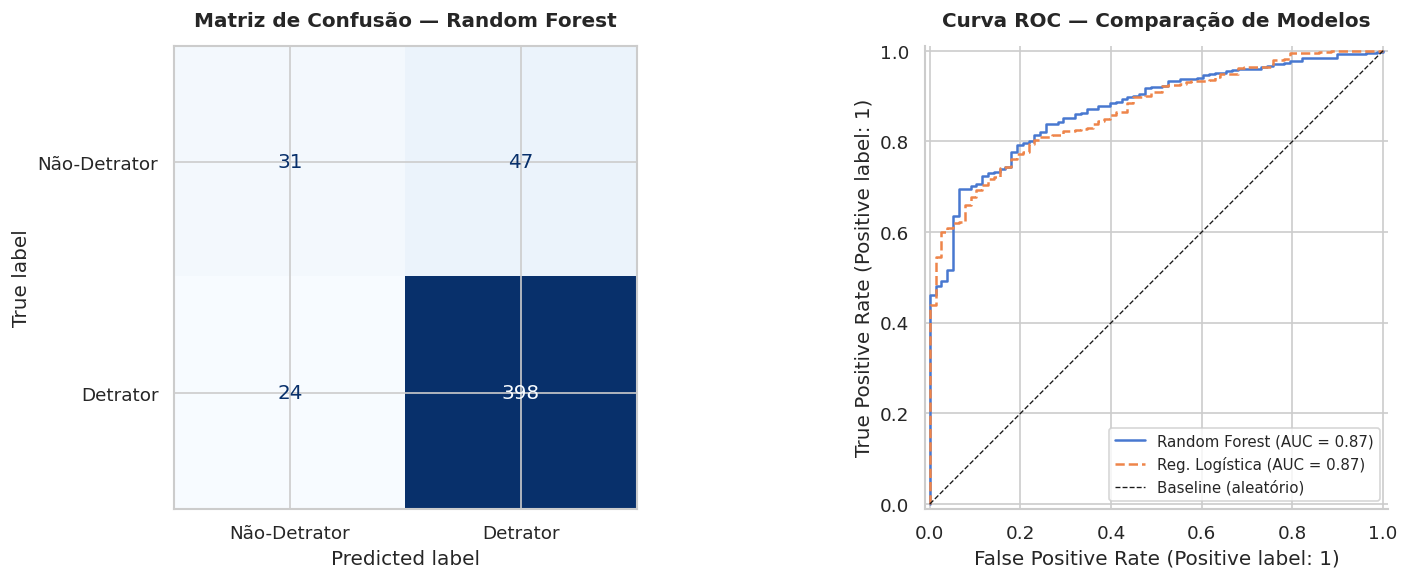


📊 Resumo da Matriz de Confusão:
  ✅ Detratores identificados corretamente (VP): 398
  ❌ Detratores não identificados (FN):          24  ← erro mais custoso
  ⚠️  Não-detratores sinalizados como risco (FP): 47  ← ação desnecessária mas inofensiva
  ✅ Não-detratores corretos (VN):                31
A Curva ROC mostra que o Random Forest separa bem detratores de não-detratores.
Quanto mais a curva se afasta da diagonal tracejada (chute aleatório), melhor.


In [ ]:
# ============================================================
# MATRIZ DE CONFUSÃO
# Mostra os acertos e erros do modelo de forma visual
#
# Como ler:
#   Verdadeiro Negativo (VN) → Não-detrator previsto corretamente
#   Falso Positivo (FP)      → Não-detrator previsto como detrator
#   Falso Negativo (FN)      → Detrator não identificado (pior erro)
#   Verdadeiro Positivo (VP) → Detrator identificado corretamente
# ============================================================

cm = confusion_matrix(y_test, y_pred_rf)
vn, fp, fn, vp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico A: Matriz de confusão ---
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não-Detrator', 'Detrator']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Random Forest', fontsize=12, fontweight='bold', pad=12)

# --- Gráfico B: Curva ROC ---
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], name='Random Forest')
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=axes[1], name='Reg. Logística', linestyle='--')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Baseline (aleatório)')
axes[1].set_title('Curva ROC — Comparação de Modelos', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f'\n📊 Resumo da Matriz de Confusão:')
print(f'  ✅ Detratores identificados corretamente (VP): {vp}')
print(f'  ❌ Detratores não identificados (FN):          {fn}  ← erro mais custoso')
print(f'  ⚠️  Não-detratores sinalizados como risco (FP): {fp}  ← ação desnecessária mas inofensiva')
print(f'  ✅ Não-detratores corretos (VN):                {vn}')

print(f'A Curva ROC mostra que o Random Forest separa bem detratores de não-detratores.')
print(f'Quanto mais a curva se afasta da diagonal tracejada (chute aleatório), melhor.')


---
## 7. O Que o Modelo Aprendeu? — Importância das Variáveis

Uma das grandes vantagens do Random Forest é nos dizer
**quais variáveis mais pesaram na decisão de classificar um cliente como detrator**.

Isso não é só um resultado técnico, é uma recomendação operacional.
As variáveis mais importantes são exatamente onde a empresa deve concentrar esforços.

> 💬 Isso seria como o modelo nos dizendo "eu tomei essa decisão principalmente por causa do atraso e das reclamações". Isso pode confirmar ou contradizer nossa intuição, e nos dá segurança para agir.


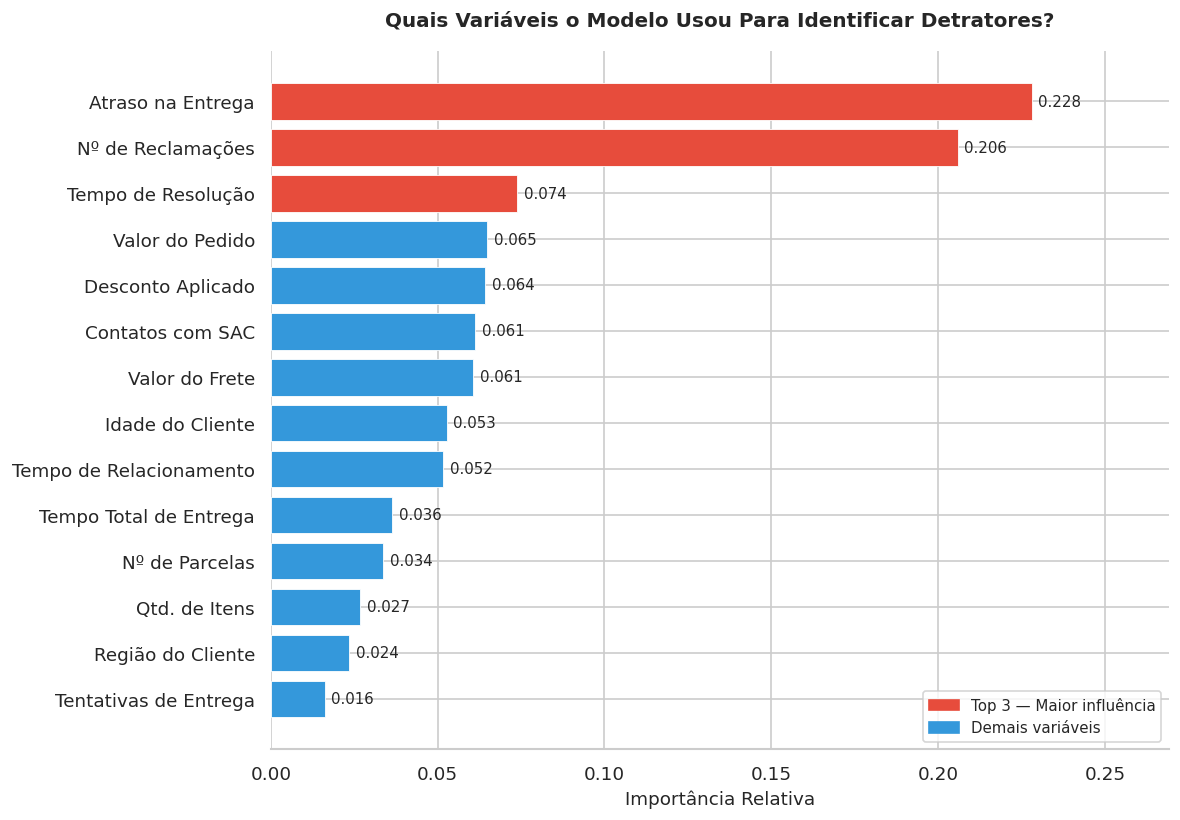

As barras vermelhas são as variáveis que mais pesam na decisão do modelo.
Elas confirmam exatamente o que a análise exploratória já havia indicado:
  → Atraso na entrega e reclamações dominam a predição.
  → Isso não é coincidência — é o modelo aprendendo o que os dados mostram.

Essa lista é uma lista de prioridades operacionais.


In [ ]:
# ============================================================
# IMPORTÂNCIA DAS FEATURES — RANDOM FOREST
# Feature Importance mede quanto cada variável contribuiu
# para as decisões do modelo (média entre todas as árvores)
# ============================================================

nomes_legíveis = {
    'delivery_delay_days'       : 'Atraso na Entrega',
    'complaints_count'          : 'Nº de Reclamações',
    'customer_service_contacts' : 'Contatos com SAC',
    'resolution_time_days'      : 'Tempo de Resolução',
    'freight_value'             : 'Valor do Frete',
    'customer_age'              : 'Idade do Cliente',
    'customer_tenure_months'    : 'Tempo de Relacionamento',
    'delivery_time_days'        : 'Tempo Total de Entrega',
    'items_quantity'            : 'Qtd. de Itens',
    'payment_installments'      : 'Nº de Parcelas',
    'discount_value'            : 'Desconto Aplicado',
    'delivery_attempts'         : 'Tentativas de Entrega',
    'order_value'               : 'Valor do Pedido',
    'customer_region'           : 'Região do Cliente'
}

importancias = pd.Series(
    rf.feature_importances_,
    index=[nomes_legíveis.get(f, f) for f in features]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

cores = ['#e74c3c' if i >= len(importancias) - 3 else '#3498db'
         for i in range(len(importancias))]

bars = ax.barh(importancias.index, importancias.values,
               color=cores, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importância Relativa', fontsize=11)
ax.set_title('Quais Variáveis o Modelo Usou Para Identificar Detratores?',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, importancias.max() * 1.18)

# Legenda manual
from matplotlib.patches import Patch
legenda = [
    Patch(color='#e74c3c', label='Top 3 — Maior influência'),
    Patch(color='#3498db', label='Demais variáveis')
]
ax.legend(handles=legenda, fontsize=9, loc='lower right')

sns.despine(left=True)
plt.tight_layout()
plt.show()

print('As barras vermelhas são as variáveis que mais pesam na decisão do modelo.')
print('Elas confirmam exatamente o que a análise exploratória já havia indicado:')
print('  → Atraso na entrega e reclamações dominam a predição.')
print('  → Isso não é coincidência — é o modelo aprendendo o que os dados mostram.')
print('\nEssa lista é uma lista de prioridades operacionais.')


---
## 8. Validação Cruzada — O Modelo É Consistente?

Treinar e testar uma única vez pode gerar resultados favoráveis por sorte,
dependendo de quais clientes caíram em cada conjunto.

A **validação cruzada** divide os dados em 5 partes, treina o modelo 5 vezes
(cada vez usando uma parte diferente como teste) e calcula a média dos resultados.

> 💬 Se o resultado for consistente nas 5 rodadas, podemos confiar que o modelo realmente aprendeu algo, não foi sorte de uma divisão específica.


In [ ]:
# ============================================================
# VALIDAÇÃO CRUZADA — 5 FOLDS
# Avalia a estabilidade do modelo em 5 divisões diferentes dos dados
# scoring='f1' → usamos F1 como métrica principal (foco nos detratores)
# ============================================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='f1', n_jobs=-1)
scores_lr = cross_val_score(lr, X, y, cv=cv, scoring='f1', n_jobs=-1)

print('=== Validação Cruzada — F1-Score (5 Folds) ===\n')

print('Random Forest:')
for i, s in enumerate(scores_rf, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Média : {scores_rf.mean():.4f} ± {scores_rf.std():.4f}')

print('\nRegressão Logística:')
for i, s in enumerate(scores_lr, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Média : {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

print(f'\n✅ Desvio padrão baixo = modelo consistente entre diferentes amostras.')
print('Isso significa que o desempenho não depende de uma divisão específica dos dados.')


=== Validação Cruzada — F1-Score (5 Folds) ===

Random Forest:
  Fold 1: 0.9222
  Fold 2: 0.9195
  Fold 3: 0.9243
  Fold 4: 0.9204
  Fold 5: 0.9134
  Média : 0.9200 ± 0.0037

Regressão Logística:
  Fold 1: 0.8605
  Fold 2: 0.8758
  Fold 3: 0.8700
  Fold 4: 0.8776
  Fold 5: 0.8686
  Média : 0.8705 ± 0.0061

✅ Desvio padrão baixo = modelo consistente entre diferentes amostras.
Isso significa que o desempenho não depende de uma divisão específica dos dados.


---
## 9. Como Isso Funcionaria na Prática?

Um modelo que fica guardado num notebook não serve para nada.
O valor real está em integrá-lo à operação da empresa.

### Fluxo de Uso Real

Pedido entregue (ou atraso detectado)

↓

Sistema coleta os dados operacionais
(atraso, reclamações, contatos com SAC…)

↓

Modelo classifica: DETRATOR ou NÃO-DETRATOR

↓

Se DETRATOR → acionar régua de recuperação:

• Contato proativo do SAC antes da reclamação

• Cupom de compensação proporcional ao problema

• Prioridade na fila de atendimento

↓

Pesquisa de NPS aplicada depois

(agora com chance real de reverter a nota)


> 💬 Hoje a empresa é como um médico que só descobre que o paciente ficou insatisfeito depois da alta. Com o modelo, passamos a monitorar sinais vitais durante a internação e podemos agir antes que o quadro piore.



In [ ]:
# ============================================================
# SIMULAÇÃO — PREDIÇÃO PARA UM PEDIDO ESPECÍFICO
# Mostra como o modelo seria usado no dia a dia da operação
# ============================================================

# Exemplo de pedido com características de risco alto
pedido_risco_alto = pd.DataFrame([{
    'customer_age'              : 35,
    'customer_region'           : le.transform(['Nordeste'])[0],
    'customer_tenure_months'    : 12,
    'order_value'               : 450.00,
    'items_quantity'            : 3,
    'discount_value'            : 20.00,
    'payment_installments'      : 6,
    'delivery_time_days'        : 10,
    'delivery_delay_days'       : 5,    # ← atraso alto
    'freight_value'             : 38.00,
    'delivery_attempts'         : 2,
    'customer_service_contacts' : 4,    # ← muitos contatos SAC
    'resolution_time_days'      : 8,    # ← resolução lenta
    'complaints_count'          : 6     # ← muitas reclamações
}])

# Exemplo de pedido com baixo risco
pedido_risco_baixo = pd.DataFrame([{
    'customer_age'              : 42,
    'customer_region'           : le.transform(['Sul'])[0],
    'customer_tenure_months'    : 60,
    'order_value'               : 380.00,
    'items_quantity'            : 2,
    'discount_value'            : 15.00,
    'payment_installments'      : 3,
    'delivery_time_days'        : 7,
    'delivery_delay_days'       : 0,    # ← entrega no prazo
    'freight_value'             : 29.00,
    'delivery_attempts'         : 1,
    'customer_service_contacts' : 0,    # ← nenhum contato SAC
    'resolution_time_days'      : 0,    # ← sem problema para resolver
    'complaints_count'          : 1     # ← quase sem reclamações
}])

def avaliar_pedido(pedido, nome):
    pred       = rf.predict(pedido)[0]
    proba_det  = rf.predict_proba(pedido)[0][1]
    proba_nao  = rf.predict_proba(pedido)[0][0]
    status     = '🔴 DETRATOR' if pred == 1 else '🟢 NÃO-DETRATOR'

    print(f'\n{"="*50}')
    print(f'  Pedido: {nome}')
    print(f'  Classificação : {status}')
    print(f'  Probabilidade de ser detrator    : {proba_det:.1%}')
    print(f'  Probabilidade de não ser detrator: {proba_nao:.1%}')
    print(f'{"="*50}')

    if pred == 1:
        print('  ⚡ Ação recomendada:')
        print('     → Contato proativo do SAC')
        print('     → Avaliar cupom de compensação')
        print('     → Priorizar na fila de atendimento')
    else:
        print('  ✅ Nenhuma ação urgente necessária.')
        print('     → Seguir fluxo padrão de pós-venda')

avaliar_pedido(pedido_risco_alto,  'Perfil de Risco Alto')
avaliar_pedido(pedido_risco_baixo, 'Perfil de Risco Baixo')



  Pedido: Perfil de Risco Alto
  Classificação : 🔴 DETRATOR
  Probabilidade de ser detrator    : 99.7%
  Probabilidade de não ser detrator: 0.3%
  ⚡ Ação recomendada:
     → Contato proativo do SAC
     → Avaliar cupom de compensação
     → Priorizar na fila de atendimento

  Pedido: Perfil de Risco Baixo
  Classificação : 🟢 NÃO-DETRATOR
  Probabilidade de ser detrator    : 14.4%
  Probabilidade de não ser detrator: 85.6%
  ✅ Nenhuma ação urgente necessária.
     → Seguir fluxo padrão de pós-venda


---
## 10. Limitações e Cuidados com o Modelo


### ⚠️ Limitações que a empresa deve conhecer

**1. Viés de resposta**  
A base foi construída com clientes que responderam à pesquisa de NPS.
Quem não respondeu pode ter um perfil diferente. O modelo aprende com quem respondeu, não com todos os clientes.

**2. O modelo reflete o passado**  
Se a operação mudar significativamente (nova transportadora, novo sistema de SAC, mudança no prazo prometido), o modelo precisa ser retreinado com os novos dados.

**3. Desbalanceamento das classes**  
Com 84% de detratores na base, o modelo tem muito mais exemplos de insatisfação para aprender do que de satisfação. Isso pode fazer com que ele seja mais agressivo em classificar clientes como detratores.
Monitorar os falsos positivos no uso real é essencial.

**4. Correlação não é causa**  
O modelo identifica padrões, não explica *por que* um cliente ficou insatisfeito. Atraso e reclamações aparecem como preditores fortes, mas a causa raiz pode estar em processos mais profundos que os dados disponíveis não capturam completamente.

**5. Privacidade e ética**  
Decisões sobre atendimento ao cliente baseadas em score preditivo devem ser aplicadas para melhorar a experiência, nunca para discriminar ou priorizar clientes de forma antiética.


---
## 11. Conclusão — Do Dado à Decisão

### O que foi construído

| Etapa | Decisão tomada |
|---|---|
| **Variável alvo** | Classificação binária: Detrator vs. Não-Detrator |
| **Features** | 14 variáveis operacionais (excluindo leakage) |
| **Separação** | 80% treino / 20% teste, estratificado |
| **Modelo** | Random Forest com class_weight balanceado |
| **Avaliação** | F1-Score, ROC-AUC, Matriz de Confusão, Cross-Validation |

---

### O que o modelo entrega para o negócio

1. **Identificação antecipada de risco** → saber que um cliente tem alta probabilidade de ser detrator antes da pesquisa chegar

2. **Priorização de ações** → concentrar esforços proativos de SAC aos clientes com maior risco, não em todos igualmente

3. **Evidência para decisões operacionais** → as variáveis mais importantes do modelo são uma lista de prioridades para logística e atendimento

4. **Base para evolução** → com mais dados e feedback do uso real, o modelo pode ser refinado, retreinado e melhorado continuamente

---

> 💬 Hoje a empresa pergunta "você ficou satisfeito?" depois que tudo aconteceu. Com este modelo, passamos a perguntar
 "esse cliente está em risco?", enquanto ainda dá tempo de agir.
 Essa é a diferença entre gestão reativa e gestão preditiva.
